In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
housing = pd.read_csv('housing.csv')

In [3]:
housing.shape

(20640, 10)

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Missing Values Analysis

In [8]:
print(housing.isnull().sum())

missing_percent = (housing.isnull().sum() / len(housing)) * 100
print("\nMissing Percentage:\n", missing_percent)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing Percentage:
 longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


## Data Insights

- Median income has a strong positive correlation with house prices, indicating that areas with higher income tend to have higher housing values.
- Location features like latitude and longitude also influence pricing, showing geographical dependency.
- Features like total rooms and households contribute to understanding housing density and living conditions.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

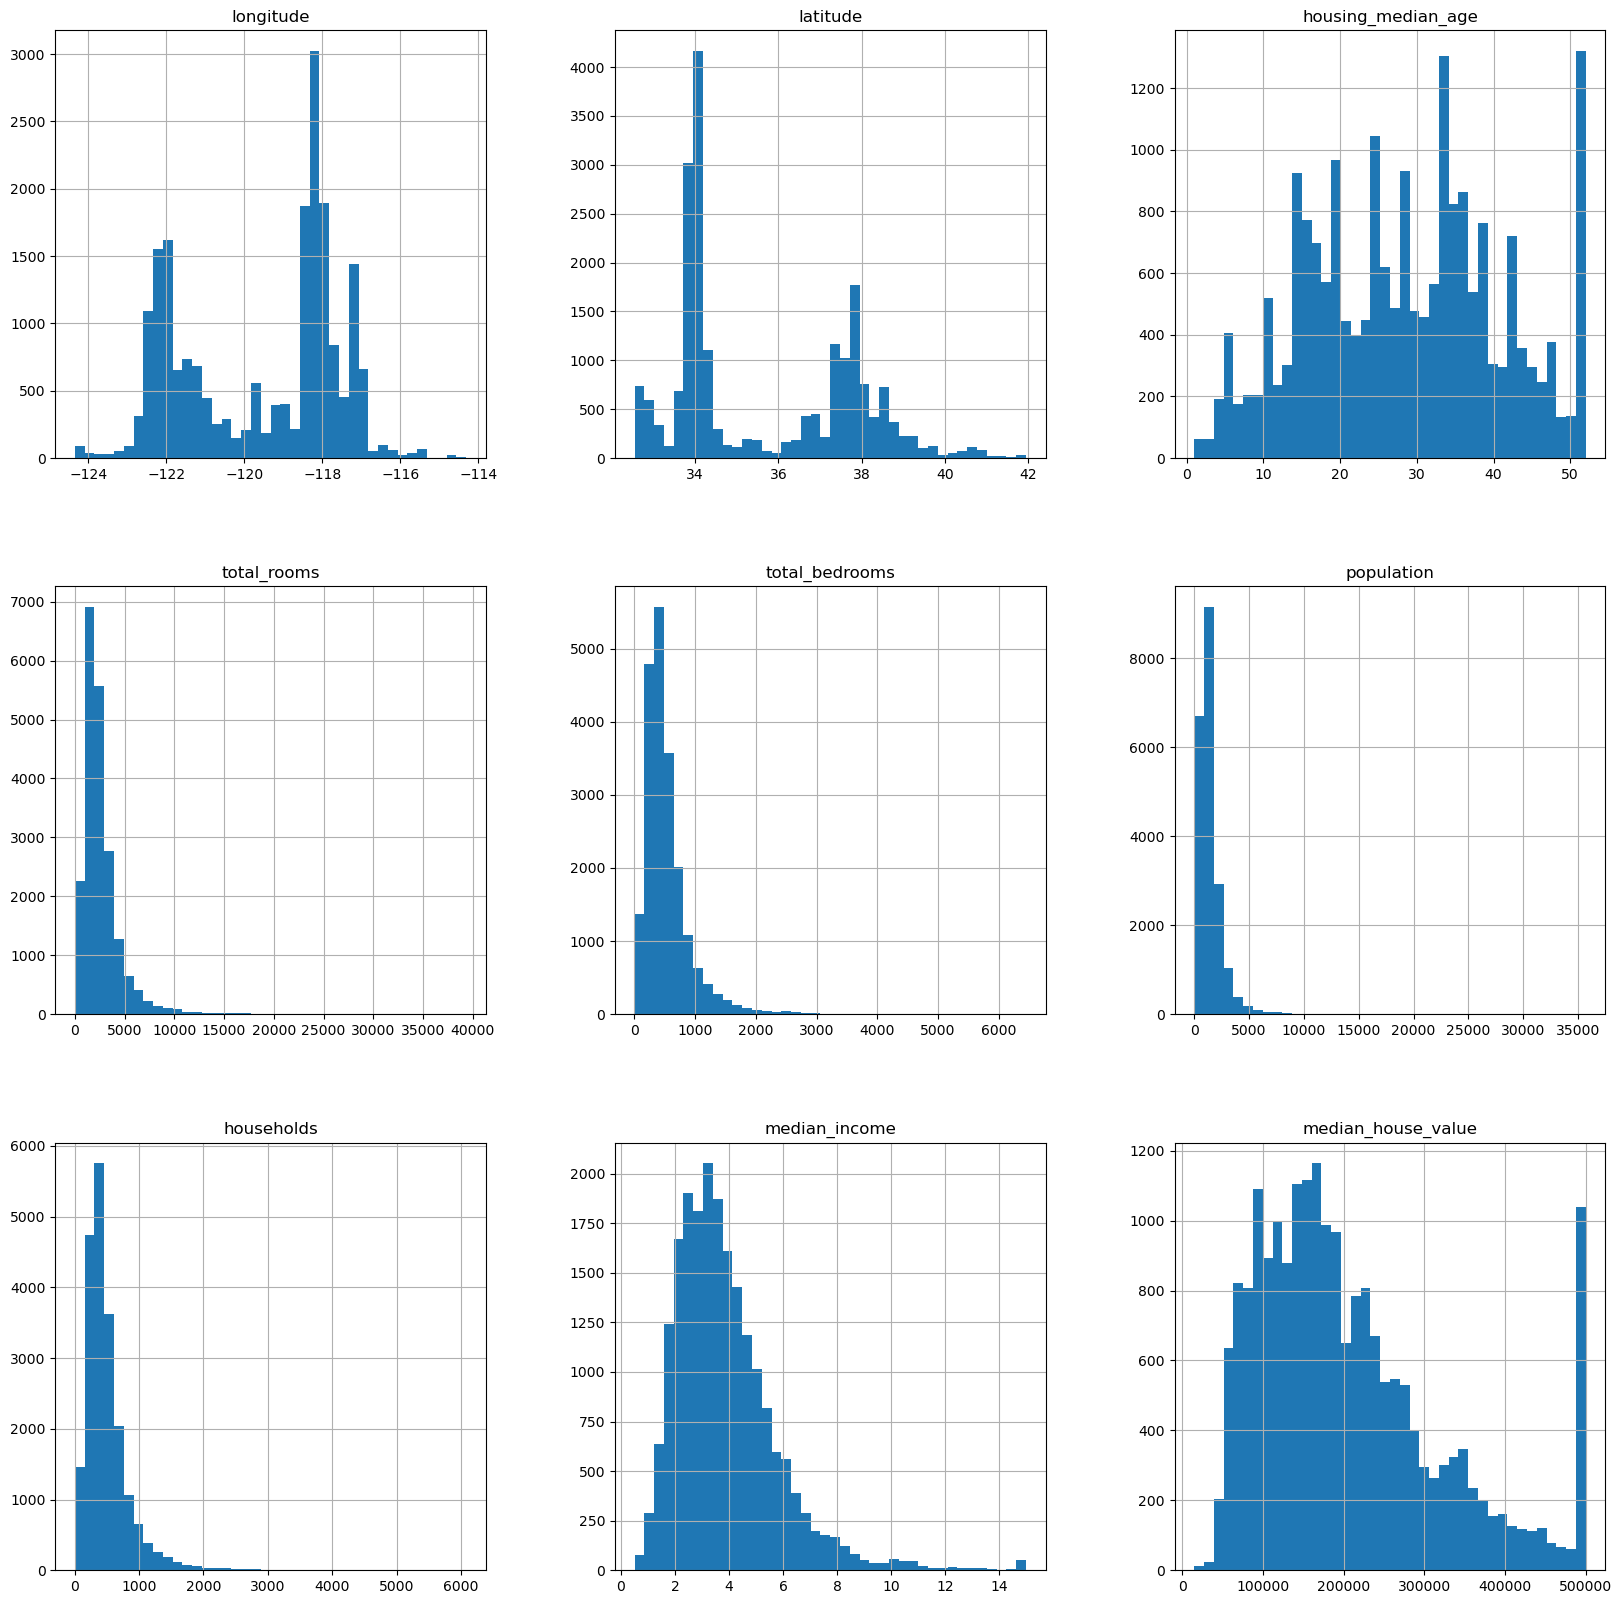

In [9]:
housing.hist(bins=40, figsize=(20,20))

<Axes: xlabel='longitude', ylabel='latitude'>

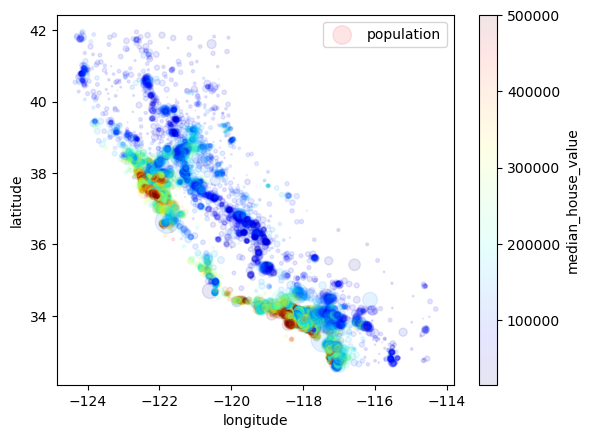

In [10]:
housing.plot(kind="scatter", x="longitude", y="latitude", 
             alpha =0.1, s=housing['population']/100, label='population',
             c='median_house_value', cmap=plt.get_cmap('jet'))

In [12]:
corr_matrix=housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

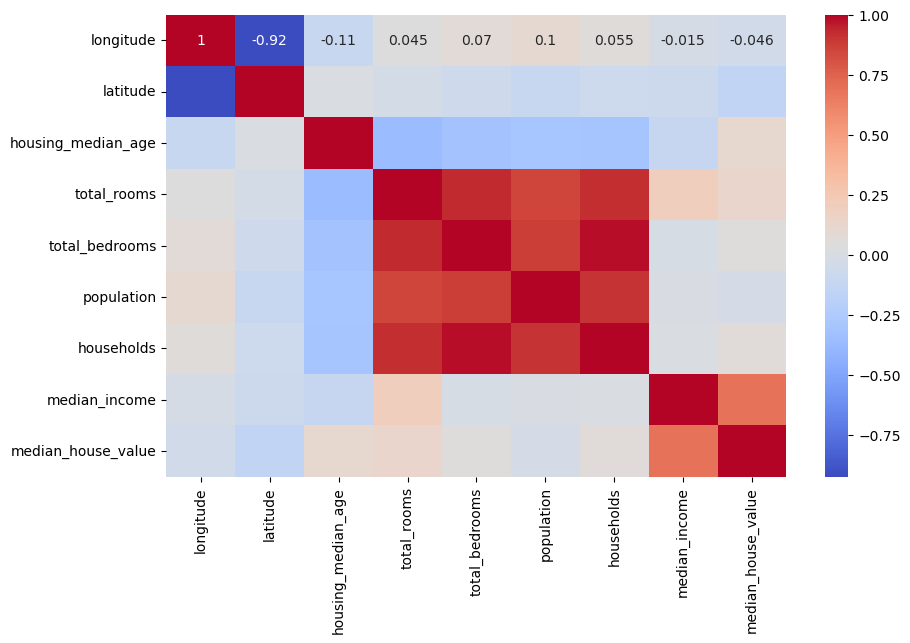

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Feature Engineering

In [14]:
housing['rooms_per_household'] =housing['total_rooms'] / housing['households']
housing['bedrooms_per_household'] =housing['total_bedrooms'] / housing['households']
housing['population_per_household'] =housing['population'] / housing['households']

In [15]:
from sklearn.model_selection import train_test_split

X = housing.drop('median_house_value', axis=1)
y = housing['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_features= X.select_dtypes(include=['int64', 'float64']).columns
cat_features = ['ocean_proximity']

num_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

preprocessor= ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [17]:
X_prepared = preprocessor.fit_transform(X_train)

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor()
}

## Model Insights & Explanation

- The Random Forest model performed better than Linear Regression in terms of RMSE and R² score.
- This is because Random Forest can capture **non-linear relationships** in the data, whereas Linear Regression assumes a linear relationship.
- Housing prices are influenced by multiple complex factors (like location, income, population), which are not strictly linear.

- Linear Regression showed comparatively lower performance because it cannot handle feature interactions and non-linearity effectively.

- The difference in performance indicates that the dataset has **complex patterns**, making ensemble models more suitable.

In [26]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_model, X_prepared, y_train, scoring="neg_mean_squared_error", cv=5)
lin_rmse = np.sqrt(-lin_scores)

rf_scores = cross_val_score(rf_model, X_prepared, y_train, scoring="neg_mean_squared_error", cv=5)
rf_rmse = np.sqrt(-rf_scores)

print("Linear RMSE:", lin_rmse.mean())
print("Random Forest RMSE:", rf_rmse.mean())

Linear RMSE: 68423.66460724732
Random Forest RMSE: 50621.09483722978


In [28]:
lin_scores = cross_val_score(lin_model, X_prepared, y_train,
                             scoring="neg_mean_squared_error", cv=5)
lin_rmse = np.sqrt(-lin_scores)

print("Linear RMSE Mean:", lin_rmse.mean())
print("Random Forest RMSE Mean:", rf_rmse.mean())

Linear RMSE Mean: 68423.66460724732
Random Forest RMSE Mean: 50621.09483722978


In [21]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=3,
                           scoring='neg_mean_squared_error')
grid_search.fit(X_prepared, y_train)

final_model = grid_search.best_estimator_
print("Best Params:", grid_search.best_params_)


Best Params: {'max_depth': None, 'n_estimators': 100}


## Evaluation Interpretation

- RMSE (Root Mean Squared Error) indicates the average prediction error in house prices. Lower RMSE means better accuracy.
- MAE (Mean Absolute Error) shows the average absolute difference between predicted and actual values.
- R² Score represents how well the model explains the variance in the data.

- A higher R² score for Random Forest suggests that it explains the data better than Linear Regression.

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R2:", r2_score(y_test, preds))


Linear Regression
RMSE: 69913.9938954297
MAE: 50212.787641539464
R2: 0.6269892359123017

Random Forest
RMSE: 49995.86853514798
MAE: 32206.57634205426
R2: 0.8092513931078785


In [ ]:
import pickle

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

final_model.fit(X_train, y_train)

pickle.dump(final_model, open("model.pkl", "wb"))

In [ ]:
print("Best model:", min(results, key=lambda x: x["RMSE"]))

## Conclusion

- Random Forest is the best-performing model for this dataset due to its ability to handle non-linear relationships and complex feature interactions.
- Cross-validation (if applied) ensures that the model performs consistently across different data splits.
- Feature engineering improved model performance by introducing meaningful ratios.
- This model can be used for predicting housing prices with reasonable accuracy in real-world scenarios.